# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
import os
os.listdir()
os.listdir('../data/')

['test.csv',
 'health_insurance_cross_sell_prediction.csv',
 'yulu_rental.csv',
 'train.csv',
 'ecom_cosmetics_sales_data.csv',
 'supermarket_sales.csv',
 'sample_submission.csv']

In [16]:
df = pd.read_csv("../data/yulu_rental.csv")

In [17]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

Висновок: У наборі даних 10886 рядків.
Рівень деталізації погодинний: один рядок = 1 година (0 days 01:00:00).

In [22]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


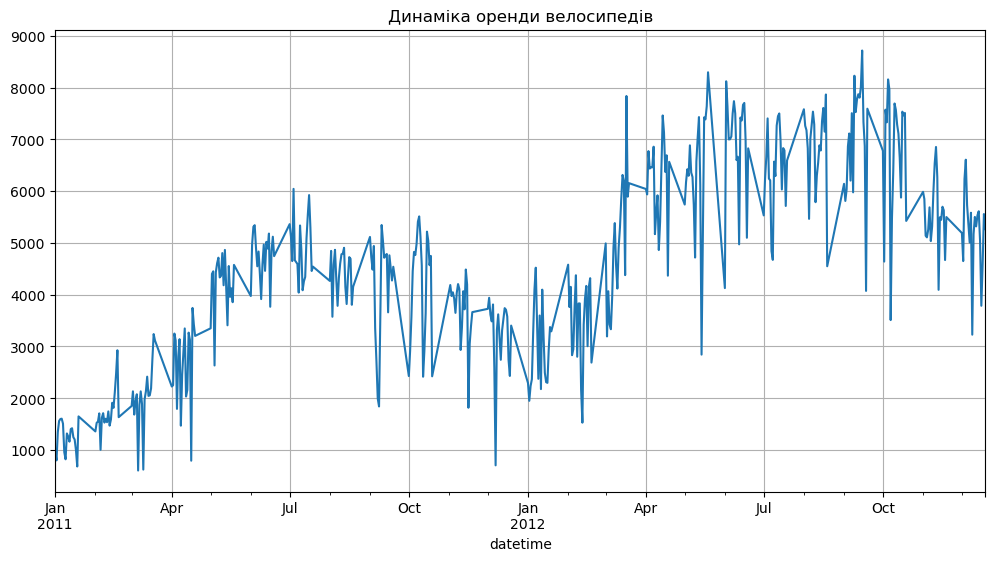

In [31]:
daily = df['count'].resample('D').sum(min_count=1).interpolate()

daily.plot(figsize=(12,6), title='Динаміка оренди велосипедів', grid=True)
plt.show()

1. Ці “заломи” до нуля виникають не тому, що оренд реально було 0, а тому що в даних є пропущені дні (в ці дні немає жодного запису)daily = df['count'].resample('D').sum(min_count=1) або interpolate() ( але виходять або розриви або ось такі дивні дотягування)
2. Кількість продажів зросла в 2012 році
3. Видно сезонність, весна-літо-осінь вищі продажі, зима - нижчі
4. Можливо якісь вихідні чи свята, або навпаки якась дуже погана погода для велосипедів. Те, що є провали до нуля, то немає даних


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

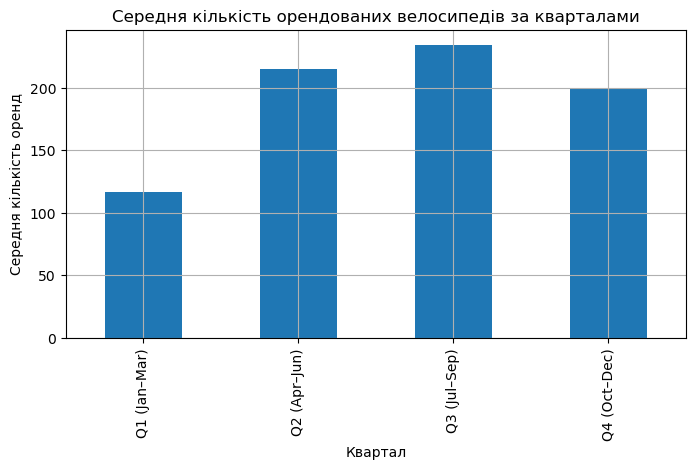

In [39]:
q_mean = df.groupby('season')['count'].mean()

labels = {
    1: 'Q1 (Jan–Mar)',
    2: 'Q2 (Apr–Jun)',
    3: 'Q3 (Jul–Sep)',
    4: 'Q4 (Oct–Dec)'
}
q_mean.index = q_mean.index.map(labels)

q_mean.plot(
    kind='bar',
    figsize=(8,4),
    title='Середня кількість орендованих велосипедів за кварталами',
    grid=True,
    xlabel = 'Квартал',
    ylabel = 'Середня кількість оренд'
)

plt.show()

1. Найбільша середня кількість оренд у Q3 (Jul–Sep).
2. Тому що season у датасеті — це квартали, і в середині року (Q2–Q3) зазвичай більше поїздок: комфортніша погода, більше активностей на вулиці.
3. Найпопулярніший — Q3, найменш — Q1. За висотами стовпчиків це приблизно:
Q3 / Q1 ≈ 234 / 117 ≈ 2.0 (приблизно в 2 рази).

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


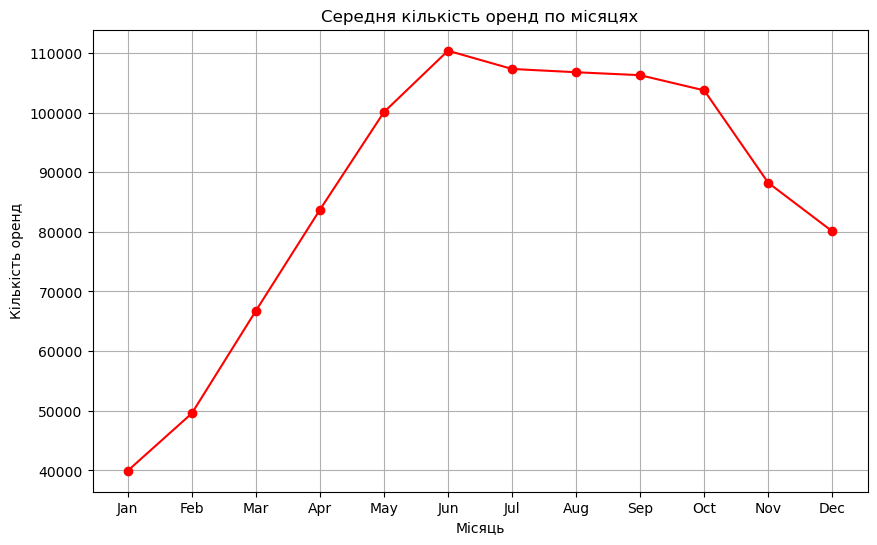

In [41]:
monthly_total = df['count'].resample('ME').sum()

monthly_sales = monthly_total.groupby(monthly_total.index.month).mean()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_sales.plot(
    kind='line',
    marker='o',
    color='red',
    figsize=(10, 6),
    title='Середня кількість оренд по місяцях',
    xlabel='Місяць',
    ylabel='Кількість оренд',
    grid=True
)

plt.xticks(range(1, 13), month_labels)

plt.show()

1.Пік - це June — найвище значення на графіку. Спад - January — найнижче значення.

2.Так, загалом збігається.
Попередній висновок: Q3 найвищий, Q1 найнижчий.
На місячному графіку теж видно, що Q1 (Jan–Mar) найслабший, а найвищі значення припадають на період Q2–Q3 (Apr–Sep).

3.Коли погода комфортна для катання на велосипеді, оренда росте. Погода псується - оренда падає

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

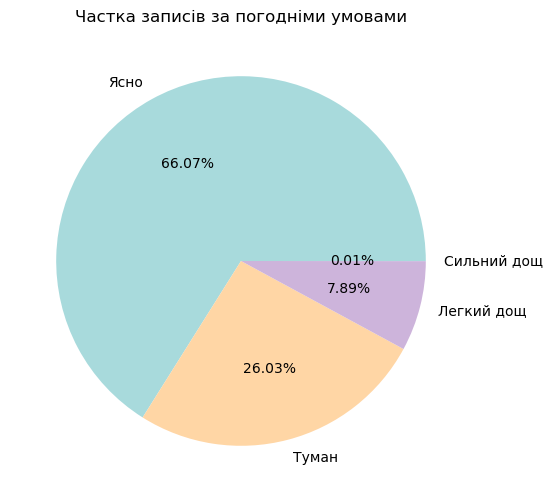

In [48]:
weather_counts = df['weather'].value_counts().sort_index()

labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
weather_counts.index = weather_counts.index.map(labels)

colors = ['#A8DADC', '#FFD6A5', '#CDB4DB', '#BDE0FE']

weather_counts.plot(
    kind='pie',
    figsize=(8, 6),
    title='Частка записів за погодніми умовами',
    autopct='%.2f%%',
    colors=colors,
    ylabel=''
)

plt.show()

1. Хороша сонячна погода
2. Так, є, але їх майже немає: приблизно 0.01% (на діаграмі це майже “нульовий” сектор).
3. Ясно  = попит вищий (комфортно, більше прогулянок). Туман = попит нижчий (менше бажання їздити).
Легкий дощ = попит помітно падає (слизько). Сильний дощ = попит різко падає (мало хто орендує).

Очікуваний результат:

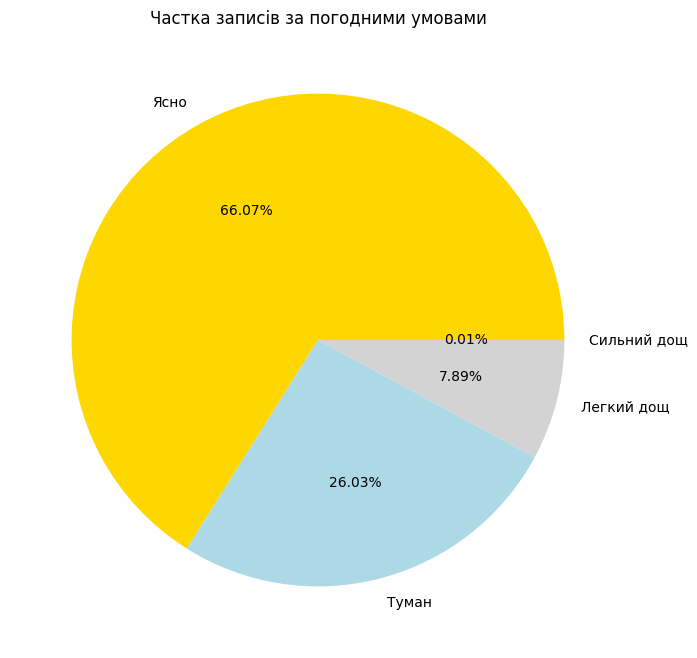

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

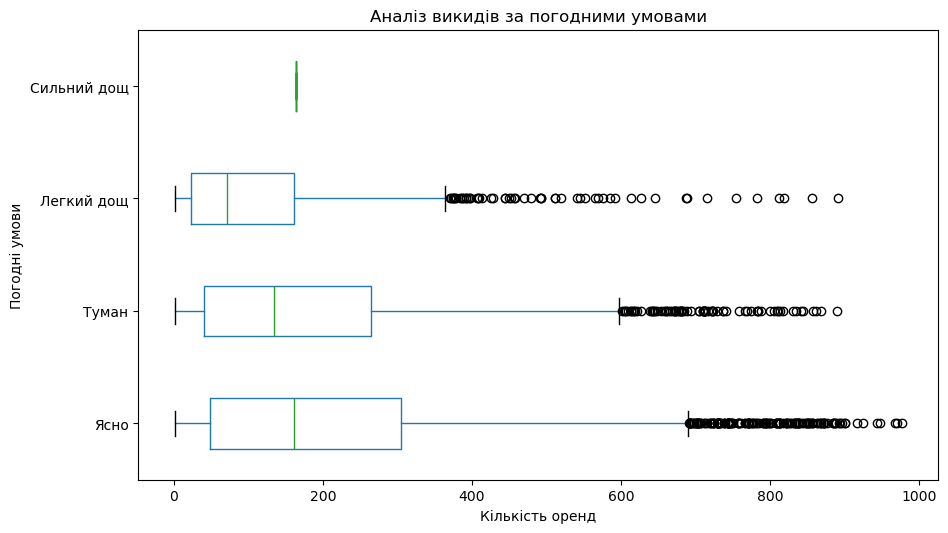

In [53]:
import pandas as pd

labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_name'] = df['weather'].map(labels)

order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
df['weather_name'] = pd.Categorical(df['weather_name'], categories=order, ordered=True)

df.boxplot(
    column='count',
    by='weather_name',
    vert=False,       
    figsize=(10, 6),
    grid=False
)

plt.title('Аналіз викидів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.show()

1.Найбільший розкид при ясній погоді

2.Так, викиди є. Найбільше їх видно при погоді: ясно та туман, і також вони є при легкому дощі, але помітно менше.
Для сильного дощу викиди майже не оцінити, бо записів дуже мало.

3.Найвище медіанне значення оренд при ясній погоді

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

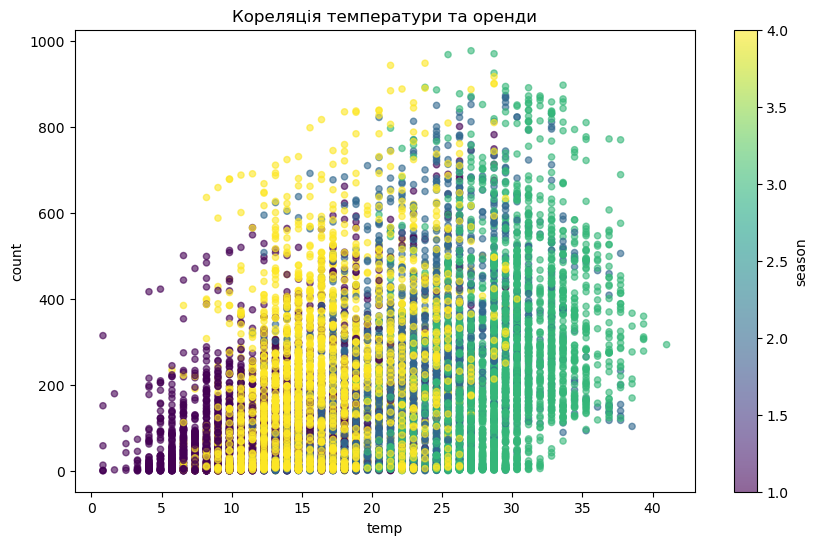

In [54]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    alpha=0.6,
    figsize=(10,6),
    title='Кореляція температури та оренди'
)
plt.show()

Так, зв’язок є, позитивний.
На графіку видно, що коли температура зростає (від холодних значень до ~25–30°C), то кількість оренд в середньому збільшується: з’являється більше точок з високими count.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

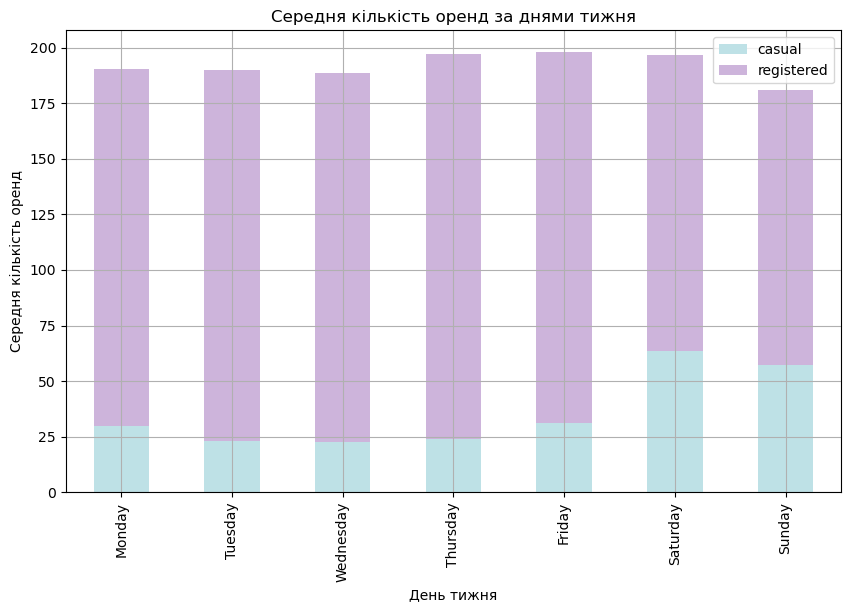

In [58]:
df['weekday'] = df.index.day_name()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avg_by_day = df.groupby('weekday')[['casual','registered']].mean().reindex(order)


avg_by_day.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    title='Середня кількість оренд за днями тижня',
    xlabel='День тижня',
    ylabel='Середня кількість оренд',
    grid=True,
    color=['#BEE1E6', '#CDB4DB']  
)

plt.show()

1. У всі дні тижня оренд від registered більше, ніж від casual.
Найбільше у будні (Monday–Friday)
2. Registered — це постійні користувачі, які їздять на роботу або навчання, тому в будні їхня активність висока. Casual — прогулянкові поїздки, тому в на вихідних